# ✅ Solutions — Module 10 — Multiple Regression

Worked solutions for every exercise of this module. **Try the exercise yourself first** — you learn statistics by *doing* it. Each solution ends with a short interpretation, because in real projects the numbers are only half of the answer.

*Every exercise is self-contained: run the setup cell below, then jump to any exercise.*

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

# --- additional tools for this module ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, train_test_split

### ✍️ Exercise 10.1 — *Partial effects & omitted-variable bias*: What drives house prices? (Real-estate valuation)

A valuation firm has data on 400 sold houses: living area, number of bedrooms, age, distance to the city centre and whether there is a garage.

**Tasks**
1. Regress price on bedrooms alone. Then fit the full model. Compare the bedroom coefficients and explain the difference.
2. Interpret every coefficient of the full model in one sentence, with its 95 % CI.
3. Which predictor matters most? Refit with **standardised** numeric predictors (z-scores) to compare.
4. Predict the price (with 95 % prediction interval) of a 140 m², 4-bedroom, 25-year-old house, 6 km from the centre, with garage.

In [2]:
g = np.random.default_rng(1001)
n = 400
area = g.uniform(60, 240, n)
hp = pd.DataFrame({"area": area.round(0), "bedrooms": np.clip(np.round(area / 38 + g.normal(0, .7, n)), 1, 7), "age": g.uniform(0, 80, n).round(0),
                   "dist_km": g.gamma(2, 4, n).round(1), "garage": np.where(g.random(n) < .2 + .002 * area, "yes", "no")})
hp["price"] = (120 + 2.9 * hp.area - 9 * hp.bedrooms - .9 * hp.age - 6.5 * hp.dist_km + 25 * (hp.garage == "yes") + g.normal(0, 38, n)).round(0)      # k€
hp.head()

,area,bedrooms,age,dist_km,garage,price
0,170.0,4.0,15.0,3.4,yes,598.0
1,63.0,2.0,52.0,12.7,no,130.0
2,94.0,2.0,69.0,5.5,no,231.0
3,214.0,5.0,34.0,21.0,no,527.0
4,74.0,1.0,42.0,6.0,no,201.0


bedrooms coefficient — alone: +74.9 k€;  in the full model: -11.2 k€

                  coef   2.5 %   97.5 %    p
Intercept      111.427  98.041  124.813  0.0
garage[T.yes]   26.787  19.301   34.274  0.0
area             2.971   2.825    3.117  0.0
bedrooms       -11.239 -16.146   -6.332  0.0
age             -0.846  -1.001   -0.691  0.0
dist_km         -6.421  -7.074   -5.767  0.0

R² = 0.939, residual SE = 36.9 k€

standardised coefficients (k€ per 1 SD):
area        152.8
dist_km     -35.8
age         -19.9
bedrooms    -17.4
dtype: float64

prediction: 450 k€, 95 % prediction interval [377, 522] k€


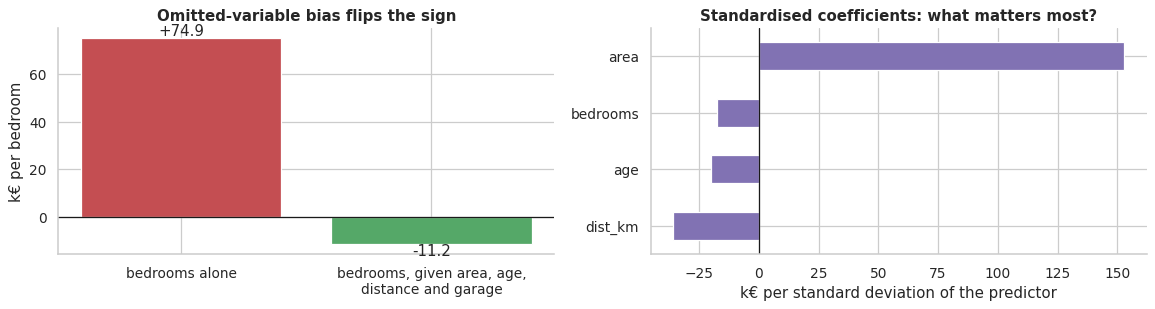

In [3]:
m_simple = smf.ols("price ~ bedrooms", hp).fit(); m_full = smf.ols("price ~ area + bedrooms + age + dist_km + garage", hp).fit()
print(f"bedrooms coefficient — alone: {m_simple.params['bedrooms']:+.1f} k€;  in the full model: {m_full.params['bedrooms']:+.1f} k€\n")
print(pd.concat([m_full.params.rename("coef"), m_full.conf_int().rename(columns={0: "2.5 %", 1: "97.5 %"}), m_full.pvalues.rename("p")], axis=1).round(3))
print(f"\nR² = {m_full.rsquared:.3f}, residual SE = {np.sqrt(m_full.mse_resid):.1f} k€")

z = hp.copy(); num = ["area", "bedrooms", "age", "dist_km"]; z[num] = (z[num] - z[num].mean()) / z[num].std()
print("\nstandardised coefficients (k€ per 1 SD):"); print(smf.ols("price ~ area + bedrooms + age + dist_km + garage", z).fit().params[num].round(1).sort_values(key=abs, ascending=False))
new = pd.DataFrame({"area": [140], "bedrooms": [4], "age": [25], "dist_km": [6], "garage": ["yes"]})
p = m_full.get_prediction(new).summary_frame().iloc[0]; print(f"\nprediction: {p['mean']:.0f} k€, 95 % prediction interval [{p.obs_ci_lower:.0f}, {p.obs_ci_upper:.0f}] k€")
zs = smf.ols("price ~ area + bedrooms + age + dist_km + garage", z).fit().params[num]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 3.6))
bars = a1.bar(["bedrooms alone", "bedrooms, given area, age,\ndistance and garage"], [m_simple.params["bedrooms"], m_full.params["bedrooms"]], color=[C[3], C[2]]); a1.bar_label(bars, fmt="%+.1f")
a1.axhline(0, color="k", lw=1); a1.set(ylabel="k€ per bedroom", title="Omitted-variable bias flips the sign")
zs.sort_values().plot.barh(ax=a2, color=C[4]); a2.axvline(0, color="k", lw=1); a2.set(xlabel="k€ per standard deviation of the predictor", title="Standardised coefficients: what matters most?"); plt.tight_layout(); plt.show()

**Interpretation.**
* **Bedrooms:** alone, each bedroom "adds" about +75 k€, because bedrooms stand in for size. With area in the model the coefficient turns **negative** (≈ −11 k€): at equal living area, more bedrooms means smaller rooms. Classic omitted-variable bias.
* **Full model (all else equal):** +1 m² ≈ +3.0 k€; +1 year of age ≈ −0.85 k€; +1 km from the centre ≈ −6.4 k€; a garage ≈ +27 k€ (its CI is the widest in relative terms — only a quarter of the houses have one).
* **Importance:** raw coefficients cannot be compared across units. Per standard deviation, **area** dominates by far (≈ 150 k€ per SD), followed by distance and age.
* **Prediction:** ≈ 450 k€ with a prediction interval of roughly ±73 k€ — the residual SE of ≈ 37 k€ is what limits the precision of single valuations, not the uncertainty of the coefficients.

### ✍️ Exercise 10.2 — *Dummy variables, adjustment & interactions*: A pay-gap audit (HR analytics)

The works council asks for an audit of the gender pay gap among 600 employees. You have salary, gender, job level and years of experience.

**Tasks**
1. Compute the **raw** pay gap (regression of salary on gender).
2. Compute the **adjusted** gap, controlling for job level and experience. Why does it differ?
3. Test whether the gap differs between job levels (interaction gender × level; nested $F$-test).
4. How are men and women distributed over the job levels? Which of the two gaps is "the" pay gap? What can the adjusted analysis *not* tell you?

In [4]:
g = np.random.default_rng(1013)
n = 600; levels = ["junior", "senior", "manager"]
gender = g.choice(["female", "male"], n, p=[.45, .55])
level = np.where(gender == "male", g.choice(levels, n, p=[.35, .40, .25]), g.choice(levels, n, p=[.50, .38, .12]))
exper = np.clip(pd.Series(level).map({"junior": 3, "senior": 10, "manager": 17}).values + g.normal(0, 3, n), 0, None).round(1)
salary = 42 + pd.Series(level).map({"junior": 0, "senior": 14, "manager": 32}).values + .9 * exper - 1.8 * (gender == "female") + g.normal(0, 6, n)
pay = pd.DataFrame({"gender": gender, "level": pd.Categorical(level, categories=levels), "exper": exper, "salary": salary.round(1)})
pay.groupby("gender").salary.agg(["count", "mean"]).round(1)

,count,mean
gender,,
female,273,57.6
male,327,64.8


In [5]:
m_raw = smf.ols("salary ~ gender", pay).fit(); m_adj = smf.ols("salary ~ gender + level + exper", pay).fit(); m_int = smf.ols("salary ~ gender * level + exper", pay).fit()
for name, mod in [("raw gap", m_raw), ("adjusted gap", m_adj)]:
    lo, hi = mod.conf_int().loc["gender[T.male]"]; print(f"{name:13s}: men earn {mod.params['gender[T.male]']:+.2f} k€  (95 % CI [{lo:.2f}, {hi:.2f}])")
print("\nDoes the gap differ by level? Nested F-test:"); print(sm.stats.anova_lm(m_adj, m_int).round(4))
print("\nshare of each gender per job level (%):"); print((pd.crosstab(pay.gender, pay.level, normalize="index") * 100).round(1))

raw gap      : men earn +7.16 k€  (95 % CI [4.32, 10.01])
adjusted gap : men earn +1.89 k€  (95 % CI [0.91, 2.87])

Does the gap differ by level? Nested F-test:
   df_resid         ssr  df_diff  ss_diff       F  Pr(>F)
0     595.0  21369.7154      0.0      NaN     NaN     NaN
1     593.0  21363.6742      2.0   6.0411  0.0838  0.9196

share of each gender per job level (%):
level   junior  senior  manager
gender                         
female    46.2    39.6     14.3
male      31.8    43.1     25.1


**Interpretation.** The **raw gap** is large (men earn about 7 k€ more on average). After adjusting for job level and experience a gap of roughly **1.9 k€** remains (95 % CI about 0.9–2.9), clearly different from zero — women are paid less than men *in comparable positions*. The interaction test gives no evidence that this adjusted gap differs between job levels.

Why do the two numbers differ? **Composition:** 25 % of men but only about 14 % of women are managers. Most of the raw gap is a *representation* gap, not unequal pay for equal work.

**Which number is "the" gap?** Both — they answer different questions. The adjusted gap measures *unequal pay for comparable work*. The raw gap also contains unequal *access* to well-paid positions. And here lies the limit of adjustment: job level may itself be affected by gender (a **mediator**) — if women are promoted less often, "controlling for level" adjusts that discrimination away. A complete audit examines promotion rates as well.

### ✍️ Exercise 10.3 — *Multicollinearity*: Which advertising channel works? (Marketing-mix modelling)

Two years of weekly data: spend on TV, online and social media (k€), a price index, and sales. Management wants to know the return of each channel. Problem: the marketing department always scales all channels up and down *together*.

**Tasks**
1. Inspect the correlation matrix of the predictors.
2. Fit the full model. Compare the overall $F$-test / $R^2$ with the individual coefficient tests. What is odd?
3. Compute the VIFs.
4. Fit a model with **total spend** instead of the three channels. What can you conclude from these data — and what not? How could the company find out?

In [6]:
g = np.random.default_rng(1003)
n = 104; budget = g.gamma(6, 10, n)
mix = pd.DataFrame({"tv": budget * .5 + g.normal(0, 3, n), "online": budget * .3 + g.normal(0, 2, n), "social": budget * .2 + g.normal(0, 1.5, n), "price_idx": g.normal(100, 5, n)}).round(1)
mix["sales"] = (200 + 1.8 * mix.tv + 3.0 * mix.online + 1.0 * mix.social - 1.5 * (mix.price_idx - 100) + g.normal(0, 25, n)).round(0)
mix.corr().round(2)

,tv,online,social,price_idx,sales
tv,1.00,0.91,0.92,-0.08,0.86
online,0.91,1.00,0.92,-0.00,0.81
social,0.92,0.92,1.00,-0.03,0.82
price_idx,-0.08,-0.00,-0.03,1.00,-0.14
sales,0.86,0.81,0.82,-0.14,1.00


R² = 0.751, overall F-test p = 4.8e-29

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    291.3090     54.024      5.392      0.000     184.114     398.504
tv             2.6397      0.617      4.278      0.000       1.415       3.864
online         1.2576      1.067      1.179      0.241      -0.859       3.374
social         1.1221      1.685      0.666      0.507      -2.222       4.466
price_idx     -0.8982      0.534     -1.682      0.096      -1.957       0.161

VIF: {'tv': 8.1, 'online': 7.9, 'social': 8.8, 'price_idx': 1.0}

total-spend model: +1 k€ spend -> +1.94 k€ sales (95 % CI [1.72, 2.17]),  R² = 0.748


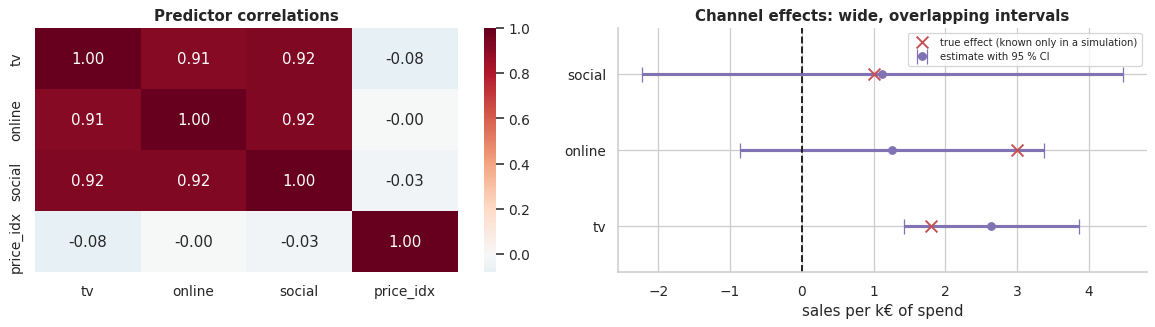

In [7]:
m = smf.ols("sales ~ tv + online + social + price_idx", mix).fit()
print(f"R² = {m.rsquared:.3f}, overall F-test p = {m.f_pvalue:.1e}\n"); print(m.summary().tables[1])
X = sm.add_constant(mix[["tv", "online", "social", "price_idx"]])
print("\nVIF:", {c: round(float(variance_inflation_factor(X.values, i)), 1) for i, c in enumerate(X.columns) if c != "const"})
mix["total"] = mix.tv + mix.online + mix.social
m_tot = smf.ols("sales ~ total + price_idx", mix).fit(); lo, hi = m_tot.conf_int().loc["total"]
print(f"\ntotal-spend model: +1 k€ spend -> {m_tot.params['total']:+.2f} k€ sales (95 % CI [{lo:.2f}, {hi:.2f}]),  R² = {m_tot.rsquared:.3f}")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 3.8))
sns.heatmap(mix[["tv", "online", "social", "price_idx"]].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=a1); a1.set_title("Predictor correlations")
ci = m.conf_int().loc[["tv", "online", "social"]]; est = m.params[["tv", "online", "social"]]
a2.errorbar(est, range(3), xerr=[est - ci[0], ci[1] - est], fmt="o", color=C[4], capsize=6, lw=2.5, label="estimate with 95 % CI"); a2.scatter([1.8, 3.0, 1.0], range(3), marker="x", s=90, color=C[3], zorder=3, label="true effect (known only in a simulation)")
a2.axvline(0, color="k", ls="--"); a2.set(yticks=range(3), yticklabels=["tv", "online", "social"], ylim=(-.6, 2.6), xlabel="sales per k€ of spend", title="Channel effects: wide, overlapping intervals"); a2.legend(fontsize=8); plt.tight_layout(); plt.show()

**Interpretation.** The model as a whole is strong ($R^2$ ≈ 0.75, overall $F$-test overwhelmingly significant) — advertising clearly drives sales. Yet the **individual** channel coefficients have wide confidence intervals; some are "not significant" and their point estimates are far from the truth (1.8 / 3.0 / 1.0). TV seems to get all the credit while online — in truth the most effective channel — looks useless. The VIFs of 8–9 explain why: the three budgets move in lock-step (pairwise correlations ≈ 0.92), so the data contain very little information about *which* channel did the work. `price_idx`, uncorrelated with the rest, has VIF ≈ 1: its uncertainty comes from noise alone, not from collinearity.

The **total-spend** model shows what the data *can* say: each additional k€ of advertising brings about 2 k€ of sales, with a tight interval.

**What to tell management:** "We know advertising works; from historical data we cannot apportion the effect to channels, because you never varied them independently." The fix is **design, not statistics**: vary the channel mix deliberately — e.g. regional (geo) experiments in which single channels are switched up or down.

### ✍️ Exercise 10.4 — *Heteroscedasticity, log-transformation & interaction*: Modelling medical insurance charges (Actuarial pricing)

A health insurer models annual medical charges from age, BMI and smoking status.

**Tasks**
1. Fit `charges ~ age + bmi + smoker`. Plot residuals vs. fitted values and run the Breusch–Pagan test.
2. Fit the same model for `np.log(charges)`. Check the residuals again.
3. Add the interaction `bmi * smoker` to the log model. Is it needed (nested $F$-test, AIC)?
4. Interpret the coefficients of the final model as **percentage effects**. What does the interaction mean in plain language?

In [8]:
g = np.random.default_rng(1004)
n = 800
ins = pd.DataFrame({"age": g.integers(18, 65, n), "bmi": g.normal(28, 5, n).clip(16, 48).round(1), "smoker": np.where(g.random(n) < .2, "yes", "no")})
ins["charges"] = np.exp(7.6 + .033 * ins.age + .012 * (ins.bmi - 28) + (1.0 + .045 * (ins.bmi - 28)) * (ins.smoker == "yes") + g.normal(0, .35, n)).round(0)
ins.groupby("smoker").charges.describe().round(0)

,count,mean,std,min,25%,50%,75%,max
smoker,,,,,,,,
no,651.0,9254.0,5458.0,1314.0,5135.0,7826.0,11921.0,30726.0
yes,149.0,26657.0,19743.0,4828.0,14024.0,20916.0,33608.0,120689.0


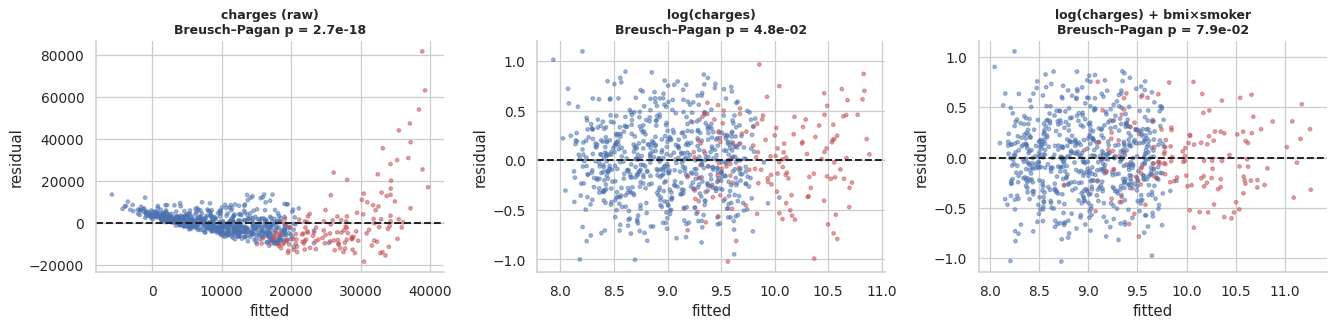

nested F-test for the interaction:
   df_resid       ssr  df_diff  ss_diff        F  Pr(>F)
0     796.0  110.6346      0.0      NaN      NaN     NaN
1     795.0  103.2464      1.0   7.3882  56.8891     0.0
AIC: without 696, with interaction 642

percentage effects (final model):
smoker[T.yes]       -36.8
age                   3.4
bmi                   1.3
bmi:smoker[T.yes]     5.3
dtype: float64

smoker vs non-smoker at BMI 22: ×1.97,  at BMI 35: ×3.86


In [9]:
m_raw = smf.ols("charges ~ age + bmi + smoker", ins).fit(); m_log = smf.ols("np.log(charges) ~ age + bmi + smoker", ins).fit(); m_int = smf.ols("np.log(charges) ~ age + bmi * smoker", ins).fit()
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, mod, name in zip(axes, [m_raw, m_log, m_int], ["charges (raw)", "log(charges)", "log(charges) + bmi×smoker"]):
    ax.scatter(mod.fittedvalues, mod.resid, s=8, alpha=.5, c=(ins.smoker == "yes").map({True: C[3], False: C[0]})); ax.axhline(0, color="k", ls="--")
    ax.set(title=f"{name}\nBreusch–Pagan p = {het_breuschpagan(mod.resid, mod.model.exog)[1]:.1e}", xlabel="fitted", ylabel="residual"); ax.title.set_fontsize(10)
plt.tight_layout(); plt.show()
print("nested F-test for the interaction:"); print(sm.stats.anova_lm(m_log, m_int).round(4)); print(f"AIC: without {m_log.aic:.0f}, with interaction {m_int.aic:.0f}\n")
pct = (np.exp(m_int.params) - 1) * 100
print("percentage effects (final model):"); print(pct.drop("Intercept").round(1))
b = m_int.params; print(f"\nsmoker vs non-smoker at BMI 22: ×{np.exp(b['smoker[T.yes]'] + 22 * b['bmi:smoker[T.yes]']):.2f},  at BMI 35: ×{np.exp(b['smoker[T.yes]'] + 35 * b['bmi:smoker[T.yes]']):.2f}")

**Interpretation.**
* **Raw model:** the residual plot fans out strongly and smokers (red) form a separate, badly fitted cloud; Breusch–Pagan rejects constant variance emphatically. Costs are generated *multiplicatively* (percentage effects), so an additive model on the euro scale is the wrong shape.
* **Log model:** the funnel disappears. But the smokers' residuals still show a slope → something is missing.
* **Interaction:** the nested $F$-test and AIC agree that `bmi:smoker` is needed; afterwards the residuals are structureless.
* **Reading the final model:** each year of age raises expected charges by ≈ 3.4 %. For **non-smokers** one BMI point adds ≈ 1.3 %; for **smokers** it adds about 1.3 % + 5.3 % ≈ 6.7 % — obesity and smoking *compound*. Consequently "the smoker effect" is not one number: smokers cost about twice as much as non-smokers at BMI 22, but almost four times as much at BMI 35. (The `smoker[T.yes]` main effect alone refers to BMI = 0 and is meaningless — centre BMI to make it interpretable.)

### ✍️ Exercise 10.5 — *Overfitting & regularisation*: Predicting diabetes progression (Medical prognosis, real data)

Using the diabetes data from section 8, a researcher wants to allow for non-linearities and interactions and expands the 10 predictors to all squares and pairwise products — **65 features** for a few hundred patients.

**Tasks**
1. Split the data (75 % training, 25 % test). Compare three pipelines on the expanded features: plain OLS, `RidgeCV`, `LassoCV` (always standardise first). Report training and test RMSE.
2. For reference: test RMSE of plain OLS on the original 10 features.
3. How many of the 65 features does the lasso keep? Which have the largest coefficients?
4. What do you conclude about flexible models, and why must the test set stay untouched until the end?

In [10]:
diab = load_diabetes(as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(diab.data, diab.target, test_size=.25, random_state=0)
expand = lambda: PolynomialFeatures(degree=2, include_bias=False)
print(X_train.shape, "->", expand().fit_transform(X_train).shape)

(331, 10) -> (331, 65)


                           train RMSE  test RMSE
OLS, 10 original features        52.7       56.4
OLS, 65 features                 47.0       61.3
Ridge (CV), 65 features          49.7       57.3
Lasso (CV), 65 features          51.4       56.9

lasso keeps 18 of 65 features (chosen alpha = 3.25); largest:
bmi        28.5
s5         23.7
bp         10.0
s3         -7.7
age sex     6.1
age s6      4.6
sex^2      -3.2
bmi bp      2.8
dtype: float64


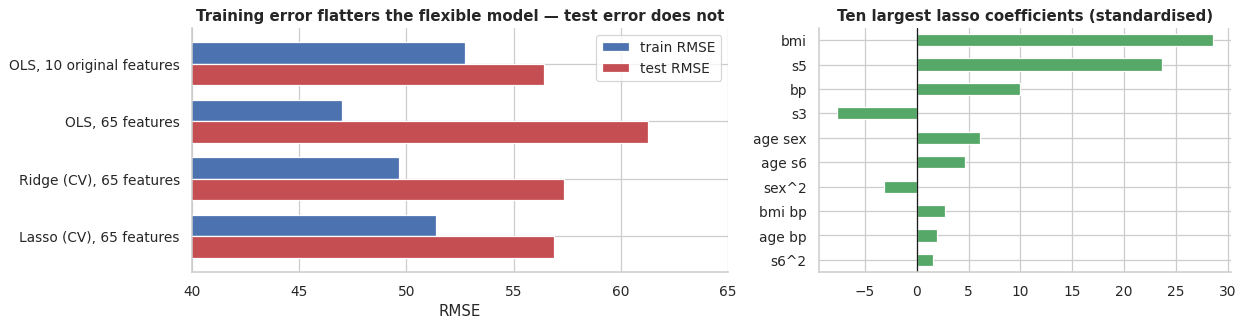

In [11]:
rmse = lambda mod, X, y: np.sqrt(np.mean((mod.predict(X) - y) ** 2))
models = {"OLS, 10 original features": make_pipeline(StandardScaler(), LinearRegression()),
          "OLS, 65 features": make_pipeline(expand(), StandardScaler(), LinearRegression()),
          "Ridge (CV), 65 features": make_pipeline(expand(), StandardScaler(), RidgeCV(alphas=np.logspace(-2, 4, 60))),
          "Lasso (CV), 65 features": make_pipeline(expand(), StandardScaler(), LassoCV(cv=5, random_state=0, max_iter=50_000))}
rows = {name: {"train RMSE": rmse(mod.fit(X_train, y_train), X_train, y_train), "test RMSE": rmse(mod, X_test, y_test)} for name, mod in models.items()}
print(pd.DataFrame(rows).T.round(1))
lasso = models["Lasso (CV), 65 features"]; coef = pd.Series(lasso[-1].coef_, index=lasso[0].get_feature_names_out(diab.data.columns))
print(f"\nlasso keeps {(coef != 0).sum()} of {coef.size} features (chosen alpha = {lasso[-1].alpha_:.2f}); largest:"); print(coef[coef != 0].sort_values(key=abs, ascending=False).head(8).round(1))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 3.8), gridspec_kw={"width_ratios": [1.3, 1]})
pd.DataFrame(rows).T.plot.barh(ax=a1, color=[C[0], C[3]], width=.75); a1.set(xlim=(40, 65), xlabel="RMSE", title="Training error flatters the flexible model — test error does not"); a1.invert_yaxis()
coef[coef != 0].sort_values(key=abs).tail(10).plot.barh(ax=a2, color=C[2]); a2.axvline(0, color="k", lw=1); a2.set_title("Ten largest lasso coefficients (standardised)"); plt.tight_layout(); plt.show()

**Interpretation.** Expanding to 65 features makes plain OLS look *better on the training data* and **worse on the test data** than the simple 10-feature model — textbook overfitting: with 65 coefficients and ≈ 330 patients the model starts to memorise noise. Ridge and lasso, with a CV-chosen penalty, bring the test error back down to about the level of the simple model. The lasso does so with 18 of the 65 features; the usual suspects `bmi`, `s5` and `bp` lead the list, and only a few small interaction terms survive.

**Conclusions.** (1) More flexibility is not automatically better; on this dataset the signal is essentially linear and no method beats a test RMSE of roughly 56–57 — that is the noise floor of the problem. (2) Regularisation makes flexible models *safe*, not miraculous. (3) The test set is an honest referee only once: if you tune models against it, it becomes training data and the reported error turns optimistic. All tuning (here: the penalty) happens by cross-validation *inside* the training set.